# Project 5 — Natural Language Processing

**Author:** Vernon T. Cox · Data Science Student, CNM · GitHub: santed7

This notebook solves all three parts of the NLP project:

1. **Part 1** — From a CSV of famous people, pick a *reference person* and output the 10 people whose overview text is "closest" in an NLP sense. Also report the reference person's sentiment.
2. **Part 2** — Use the Wikipedia API to pull the *full* articles for the reference person and those 10 neighbors, re-rank the neighbors by similarity on the full articles, and compare (plot) the two rankings.
3. **Part 3** — Make the notebook interactive: type or choose a name and see the 10 closest people.

*Comments are written so that someone reading this cold in six months — including me — can follow what each cell does, why it exists, and what output to expect.*


## AI Assistance Statement

This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of NLP steps such as text cleaning, vectorization, and similarity ranking. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the process and interpreting the results.


## Setup — installs and imports

In [1]:
%%capture
# ONE-TIME SETUP per Colab session (re-run after a fresh runtime / "Restart runtime").
#   textblob      -> sentiment analysis (Parts 1 and 2)
#   wikipedia-api -> pull full Wikipedia article text (Part 2)
#   ipywidgets    -> the dropdown / search box in Part 3 (usually preinstalled in Colab)
# The %%capture line above hides the long, noisy pip log so the cell output stays tidy.
!pip install -q -U textblob wikipedia-api ipywidgets
!python -m textblob.download_corpora


In [2]:
# Imports (run once per session).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob                                 # sentiment analysis
from sklearn.feature_extraction.text import TfidfVectorizer   # text -> number vectors
from sklearn.neighbors import NearestNeighbors                # find the closest overviews

import wikipediaapi                                           # Part 2: full article text
from IPython.display import display, clear_output             # nice tables + widget refresh

# Show all columns of wide DataFrames instead of truncating them with "...".
pd.options.display.max_columns = 100


## Settings

All the knobs live here in one place (named constants instead of magic numbers scattered through the code). Change values **here**, not in the cells below.


In [3]:
# --- Project settings (edit these, not the code below) ---

# Where the data lives (the class-provided CSV of famous people).
CSV_URL = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"

# The DEFAULT reference person. You no longer edit a name here -- when you run
# the notebook a prompt asks you for a name (see "Choose the reference person"
# below). This default is used only if you press Enter at that prompt without
# typing anything. It MUST match a value in the CSV's 'name' column exactly
# (names come from DBpedia, e.g. "Barack Obama").
DEFAULT_NAME = "Barack Obama"

# How many similar people to return (the assignment asks for 10).
N_NEIGHBORS = 10

# How many characters of the Wikipedia article to PREVIEW in Part 2. Full articles
# are long; printing all of one floods the output, so we print just this much.
WIKI_PREVIEW_CHARS = 2000

# Wikipedia's API policy REQUIRES a user-agent string identifying the project and
# a contact. Edit this to your own details if you like.
WIKI_USER_AGENT = "cnm-ds-project5-nlp (student project; contact: santed7 on GitHub)"


# Part 1 — CSV data: nearest people + sentiment

**Goal:** pick a reference person, output the 10 people whose overview text is closest (NLP-wise), and report the reference person's sentiment.


### Load the data

In [4]:
# Read the CSV directly from the URL (no manual download needed).
# Columns are:
#   URI  -> DBpedia link for the person (we mostly ignore it)
#   name -> the person's name (what we search and match on)
#   text -> a short overview paragraph about the person (what NLP compares)
# EXPECT roughly 42,785 rows.
people = pd.read_csv(CSV_URL)
print("rows, columns:", people.shape)
people.head()


rows, columns: (42786, 3)


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


### Clean the name column into a search column (two-word names only)

We do **not** search on the original `name` column (it mixes people with
organizations and uneven name shapes). Instead we add a new `search_name`
column: genuine two-word names are copied in; anything with more or fewer than
two words becomes the placeholder `Unk Unk`. The original `name` column is left
completely unchanged, so real names are still available for display and Wikipedia.

In [ ]:
# Build a SEARCH-ONLY name column; the original 'name' column is never changed.
#   what:   create a new column 'search_name'. If a row's 'name' is exactly two
#           words, copy that (whitespace-normalized) two-word name in; for every
#           other row -- one word, three+ words, blank, or non-text -- store the
#           placeholder "Unk Unk".
#   why:    the original 'name' column mixes people with organizations and uneven
#           name shapes, so we do NOT search on it directly. Matching on a clean
#           two-word column keeps lookups consistent, while the untouched 'name'
#           column still gives us real names for display and Wikipedia lookups.
#   expect: name "Barack Obama" -> search_name "Barack Obama";
#           name "Prince"/""/"Mary Anne Smith" -> search_name "Unk Unk".
PLACEHOLDER_NAME = "Unk Unk"   # named constant instead of repeating the literal

def two_word_search_name(name):
    # Guard against NaN / numbers / other non-text values in the column.
    if not isinstance(name, str):
        return PLACEHOLDER_NAME
    # split() breaks on ANY run of whitespace and drops empty pieces, so
    # leading/trailing/double spaces do not create phantom "words".
    parts = name.split()
    if len(parts) == 2:
        return parts[0] + " " + parts[1]   # rebuilt with a single clean space
    return PLACEHOLDER_NAME

# Create the NEW column. The original 'name' column is left exactly as loaded.
people["search_name"] = people["name"].apply(two_word_search_name)

replaced = (people["search_name"] == PLACEHOLDER_NAME).sum()
print("search_name set to '" + PLACEHOLDER_NAME + "':", int(replaced))
print("two-word search_name kept:", int(len(people) - replaced))
people[["name", "search_name"]].head()


In [5]:
# Quick health check: column names, dtypes, and missing-value counts.
# We mainly care that 'text' has few or no missing entries.
people.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [6]:
# We cannot measure similarity on an empty overview, so drop rows whose 'text'
# is missing. reset_index(drop=True) renumbers the rows 0,1,2,... so each row's
# POSITION lines up exactly with its row in the TF-IDF matrix later. (This avoids
# a subtle bug where neighbor positions point at the wrong people.)
before = len(people)
people = people.dropna(subset=["text"]).reset_index(drop=True)
print("dropped", before - len(people), "rows with no overview text")
print("rows remaining:", len(people))


dropped 0 rows with no overview text
rows remaining: 42786


### Set up the Wikipedia lookup (also used as a fallback)

We create the Wikipedia client now (instead of waiting until Part 2) so the name
prompt below can fall back to Wikipedia: if you type someone who is **not** in the
class dataset -- e.g. a single-name star like Rihanna -- we pull their overview
from Wikipedia and analyze them anyway.

In [ ]:
# Wikipedia client + helpers, defined early so BOTH the Part 1 fallback (next
# cell) and Part 2 can reuse them.
#   what:   get_wiki_text(name)     -> FULL article text, or "" if no page.
#           get_wiki_overview(name) -> just the SUMMARY (lead section), or "".
#   why:    the dataset is mostly two-word names and misses single-name/current
#           stars; pulling their Wikipedia text live lets us analyze ANYONE.
#   expect: get_wiki_overview("Rihanna") returns a non-empty summary string.
wiki = wikipediaapi.Wikipedia(user_agent=WIKI_USER_AGENT, language="en")

def get_wiki_text(name):
    # Full plain text of the English Wikipedia page, or "" if no exact-title page
    # exists. Returning "" (not raising) lets callers handle a miss gracefully.
    page = wiki.page(name)
    if page.exists():
        return page.text
    return ""

def get_wiki_overview(name):
    # SUMMARY (lead section) only -- the closest analog to the dataset's short
    # 'text' overview, so a fallback person slots into the SAME TF-IDF space.
    page = wiki.page(name)
    if page.exists():
        return page.summary
    return ""


### Choose the reference person (type a name)

Run the next cell and type any person's name at the prompt. It resolves what
you type to an exact name in the data, so `obama` or `barack obama` both work.
If the name isn't found it simply asks again -- no error. Press **Enter** with
nothing typed to accept the default from Settings.

In [ ]:
# Pick the reference person at RUN TIME, with a live Wikipedia fallback.
#   what:   prompt for a name; use the dataset if it is there, otherwise pull the
#           person's overview from Wikipedia. Keep asking until something resolves.
#   why:    so you can analyze ANYONE -- people in the class CSV AND current,
#           single-name stars (Rihanna, Beyonce, Drake) who are not in it.
#   expect: prints whether the reference came from the dataset or from Wikipedia.
# COLAB NOTE: the input box appears at the TOP of this cell's output area.

# Try to match typed text to a real row in the data, using the 'search_name'
# column. Returns one of:
#   ("ok",  exact_name) -> exactly one good match; use it
#   ("many", None)      -> several partial matches; caller should ask again
#   ("none", None)      -> no match at all; caller may try Wikipedia instead
def find_in_data(typed):
    typed = typed.strip()
    if typed in set(people["search_name"]):
        return ("ok", typed)
    ci_exact = people.loc[people["search_name"].str.lower() == typed.lower(),
                          "search_name"].tolist()
    if len(ci_exact) >= 1:
        return ("ok", ci_exact[0])
    partial = people.loc[people["search_name"].str.contains(typed, case=False, na=False),
                         "search_name"].tolist()
    if len(partial) == 1:
        return ("ok", partial[0])
    if len(partial) > 1:
        print("'" + typed + "' matched " + str(len(partial)) + " names, e.g. "
              + ", ".join(partial[:10]) + ". Try a more specific name.")
        return ("many", None)
    return ("none", None)

# These describe the chosen reference person for every cell below:
#   REFERENCE_NAME     -> the name to display / look up on Wikipedia
#   REFERENCE_IN_DATA  -> True if they are a row in `people`, False if from Wikipedia
#   REFERENCE_OVERVIEW -> the overview text to analyze when NOT in the data
REFERENCE_NAME = None
REFERENCE_IN_DATA = None
REFERENCE_OVERVIEW = None

# Keep asking until we resolve a person. Press Enter (empty) to accept the default.
while REFERENCE_NAME is None:
    typed_name = input("Enter a person's name (Enter for default '" + DEFAULT_NAME + "'): ")

    if typed_name.strip() == "":
        REFERENCE_NAME = DEFAULT_NAME          # default is a real dataset name
        REFERENCE_IN_DATA = True
        break

    status, value = find_in_data(typed_name)
    if status == "ok":
        REFERENCE_NAME = value
        REFERENCE_IN_DATA = True
    elif status == "many":
        continue                               # ambiguous: ask again (not Wikipedia)
    else:
        # Not in the dataset -> try a LIVE Wikipedia lookup so single-name and
        # current celebrities (e.g. Rihanna) can still be analyzed.
        typed_clean = typed_name.strip()
        overview = get_wiki_overview(typed_clean)
        if overview.strip() != "":
            REFERENCE_NAME = typed_clean
            REFERENCE_IN_DATA = False
            REFERENCE_OVERVIEW = overview
            print("'" + REFERENCE_NAME + "' is not in the dataset -- pulled their "
                  "overview from Wikipedia instead.")
        else:
            print("'" + typed_clean + "' was not found in the dataset OR on "
                  "Wikipedia. Check the spelling and try again.")

# Report where the reference person came from.
if REFERENCE_IN_DATA:
    print("Reference person set to:", REFERENCE_NAME, "(from the dataset)")
else:
    print("Reference person set to:", REFERENCE_NAME, "(from Wikipedia)")


### Locate the reference person (dataset or Wikipedia)

In [7]:
# Locate the reference person and assemble the overview text we will analyze.
#   - in the dataset    -> ref_idx is their row position; overview = CSV 'text'.
#   - Wikipedia fallback -> no row (ref_idx = None); overview = the Wikipedia
#     summary fetched above. They are folded into the SAME TF-IDF space later via
#     vectorizer.transform(), so they need no row in `people`.
if REFERENCE_IN_DATA:
    ref_idx = people.index[people["search_name"] == REFERENCE_NAME].tolist()[0]
    REFERENCE_TEXT = people.loc[ref_idx, "text"]
    print("Reference person:", REFERENCE_NAME, "(in dataset, row position", str(ref_idx) + ")")
else:
    ref_idx = None
    REFERENCE_TEXT = REFERENCE_OVERVIEW
    print("Reference person:", REFERENCE_NAME, "(from Wikipedia; not in dataset)")
    print("Overview length (characters):", len(REFERENCE_TEXT))


Reference person: Barack Obama
Found at row position: 35811


In [8]:
# Optional manual helper: list rows whose SEARCH name CONTAINS a string
# (case-insensitive). Shows both the original 'name' and the 'search_name' used
# for matching. Change "Obama" to whoever you want to find.
# na=False keeps any blank/non-string values from breaking the search.
people[people["search_name"].str.contains("Obama", case=False, na=False)]


,URI,name,text
2936,<http://dbpedia.org/resource/Ricardo_Mangue_Ob...,Ricardo Mangue Obama Nfubea,ricardo mangue obama nfubea born c 1961 is a p...
35811,<http://dbpedia.org/resource/Barack_Obama>,Barack Obama,barack hussein obama ii brk husen bm born augu...


### Vectorize the overviews with TF-IDF

In [9]:
# Turn every overview into a numeric vector with TF-IDF.
#   - TF-IDF gives high weight to words that are DISTINCTIVE to a person and low
#     weight to words everyone uses, so "closeness" reflects meaningful overlap
#     rather than shared filler words.
#   - stop_words="english" drops common filler ("the", "and", "of", ...).
#   - max_features caps the vocabulary at the 20,000 most informative words so the
#     matrix stays a manageable size on 40k+ documents.
# EXPECT a sparse matrix shaped (number_of_people, vocabulary_size).
vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)
tfidf = vectorizer.fit_transform(people["text"])
print("TF-IDF matrix shape (people, words):", tfidf.shape)


TF-IDF matrix shape (people, words): (42786, 20000)


### Find the 10 nearest people

In [10]:
# Build a NearestNeighbors index over the TF-IDF vectors.
#   metric="cosine" compares the ANGLE between two text vectors, which is the
#   standard, length-independent way to measure document similarity (a long and a
#   short overview can still be "close" in topic).
# Fitting just stores the vectors for fast lookup; no real model training happens.
nn = NearestNeighbors(metric="cosine").fit(tfidf)
print("NearestNeighbors index ready.")


NearestNeighbors index ready.


In [11]:
# Get the reference person's TF-IDF vector, then find the 10 nearest people.
#   in-data:  the vector already sits at tfidf[ref_idx], and the closest match is
#             the person THEMSELVES (distance ~0), so we ask for N+1 and drop them.
#   fallback: the person is NOT in the corpus, so we project their Wikipedia
#             overview into the SAME TF-IDF space with transform() and ask for
#             exactly N neighbors (there is no "self" row to drop).
#   distances -> cosine distance to each neighbor (0 = identical, 1 = unrelated)
#   indices   -> row positions of those neighbors in `people`
if REFERENCE_IN_DATA:
    ref_vector = tfidf[ref_idx]
    distances, indices = nn.kneighbors(ref_vector, n_neighbors=N_NEIGHBORS + 1)
    distances, indices = distances[0], indices[0]
    neighbor_idx = indices[1:]      # drop the reference person themselves
    neighbor_dist = distances[1:]
else:
    ref_vector = vectorizer.transform([REFERENCE_TEXT])
    distances, indices = nn.kneighbors(ref_vector, n_neighbors=N_NEIGHBORS)
    neighbor_idx = indices[0]       # no self row to drop in the fallback case
    neighbor_dist = distances[0]

print("Neighbor row positions:", neighbor_idx)


Neighbor row positions: [24478 38370  2412 38708 24837 18827 40178  6796  7914  4032]


In [12]:
# Build a tidy table of the 10 closest people, nearest first.
#   rank     -> 1..10 (1 = most similar)
#   distance -> cosine distance (smaller = more similar)
# This table is the Part 1 deliverable: the 10 overviews closest to the reference.
part1_results = pd.DataFrame({
    "rank": range(1, N_NEIGHBORS + 1),
    "name": people.loc[neighbor_idx, "name"].values,
    "distance": neighbor_dist.round(4),
})
part1_results


,rank,name,distance
0,1,Joe Biden,0.6551
1,2,Samantha Power,0.6911
2,3,Joe the Plumber,0.7069
3,4,Eric Stern (politician),0.7092
4,5,Leon Panetta,0.7232
5,6,Henry Waxman,0.7309
6,7,Chuck Hagel,0.7380
7,8,Eric Holder,0.7492
8,9,Phil Schiliro,0.7499
9,10,Kenneth D. Thompson,0.7625


### Sentiment of the reference person's overview

In [13]:
# TextBlob sentiment gives two numbers:
#   polarity     -> -1.0 (negative) ... +1.0 (positive)
#   subjectivity ->  0.0 (factual)  ...  1.0 (opinionated)
# Encyclopedia-style overviews are usually fairly neutral and factual, so EXPECT a
# polarity near 0 and a low-to-moderate subjectivity.
ref_text = REFERENCE_TEXT   # CSV overview, or Wikipedia summary in the fallback case
ref_sentiment = TextBlob(ref_text).sentiment

print("Sentiment of", REFERENCE_NAME, "overview:")
print("  polarity:    ", round(ref_sentiment.polarity, 4))
print("  subjectivity:", round(ref_sentiment.subjectivity, 4))


Sentiment of Barack Obama overview:
  polarity:     0.0787
  subjectivity: 0.2787


# Part 2 — Full Wikipedia articles: re-rank and compare

**Goal:** pull the *full* Wikipedia article for the reference person and each of the 10 neighbors, re-rank the neighbors by similarity on the full articles, then compare that ranking to the Part 1 ranking (which used only the short overviews). The difference in rank is the comparison.


### Set up the Wikipedia client

In [14]:
# The Wikipedia client (`wiki`) and helpers (`get_wiki_text`, `get_wiki_overview`)
# were already defined back in Part 1 so the name prompt could fall back to
# Wikipedia. Nothing to set up again here.
print("Wikipedia client ready (defined in Part 1).")


### Step 1 — print the reference person's Wikipedia text

In [15]:
# Pull the reference person's FULL Wikipedia article.
ref_wiki_text = get_wiki_text(REFERENCE_NAME)

# Articles are long, so print only the first WIKI_PREVIEW_CHARS as a sanity check.
# (Change WIKI_PREVIEW_CHARS in Settings to preview more or less.)
print("Article length (characters):", len(ref_wiki_text))
print("-" * 60)
print(ref_wiki_text[:WIKI_PREVIEW_CHARS])


Article length (characters): 85851
------------------------------------------------------------
Barack Hussein Obama II (born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American president. Obama previously served as a U.S. senator representing Illinois from 2005 to 2008 and as an Illinois state senator from 1997 to 2004.
Born in Honolulu, Obama graduated from Columbia University in 1983 and later worked as a community organizer in Chicago. In 1988, Obama enrolled at Harvard Law School, where he was the first Black president of the Harvard Law Review. He became a civil rights attorney and an academic, teaching constitutional law at the University of Chicago Law School from 1992 to 2004. In 1996, Obama was elected to represent the 13th district in the Illinois Senate, a position he held until 2004, when he successfully ran for the U.S. Senate. In the 2008 pre

### Step 2 — sentiment of the full Wikipedia page

In [16]:
# Same TextBlob sentiment as Part 1, but on the FULL article instead of the short
# overview. EXPECT it to still be fairly neutral, though it may differ a little from
# the overview's sentiment because there is far more text to average over.
ref_wiki_sentiment = TextBlob(ref_wiki_text).sentiment
print("Sentiment of", REFERENCE_NAME, "full Wikipedia page:")
print("  polarity:    ", round(ref_wiki_sentiment.polarity, 4))
print("  subjectivity:", round(ref_wiki_sentiment.subjectivity, 4))


Sentiment of Barack Obama full Wikipedia page:
  polarity:     0.0989
  subjectivity: 0.3291


### Step 3 — collect the 10 neighbors' Wikipedia articles

In [17]:
# Download the FULL article for each of the 10 neighbors, keeping the same order
# as the Part 1 ranking. NOTE: this makes ~10 live web requests, so it takes a few
# seconds. A name with no exact Wikipedia title comes back as "" and is flagged
# below (article chars: 0).
neighbor_names = people.loc[neighbor_idx, "name"].tolist()

neighbor_wiki_texts = []
for person_name in neighbor_names:
    article = get_wiki_text(person_name)
    neighbor_wiki_texts.append(article)
    print(person_name, "-> article chars:", len(article))


Joe Biden -> article chars: 95761
Samantha Power -> article chars: 24340
Joe the Plumber -> article chars: 21563
Eric Stern (politician) -> article chars: 0
Leon Panetta -> article chars: 23495
Henry Waxman -> article chars: 14377
Chuck Hagel -> article chars: 44825
Eric Holder -> article chars: 57153
Phil Schiliro -> article chars: 2160
Kenneth D. Thompson -> article chars: 0


### Step 4 — re-rank the neighbors using the full articles

In [18]:
# Re-measure similarity on the FULL articles instead of the short overviews.
# Strategy: vectorize [reference_article] + [the 10 neighbor articles] together with
# a fresh TF-IDF, then measure each neighbor's cosine distance to the reference,
# which sits at row 0.
#
# We build the document list with the reference FIRST, then the 10 neighbors, so
# neighbor i lives at document row i+1.
wiki_docs = [ref_wiki_text] + neighbor_wiki_texts

# Fresh vectorizer for this small corpus (11 documents); no max_features needed.
# NOTE: any neighbor whose page was missing ("") becomes an all-zero vector and
# will land at the maximum distance (1.0) -- effectively ranked last, which is the
# sensible behavior for "we could not read their page."
wiki_vectorizer = TfidfVectorizer(stop_words="english")
wiki_tfidf = wiki_vectorizer.fit_transform(wiki_docs)

# Cosine distance from the reference (row 0) to every document.
wiki_nn = NearestNeighbors(metric="cosine").fit(wiki_tfidf)
w_dist, w_idx = wiki_nn.kneighbors(wiki_tfidf[0], n_neighbors=len(wiki_docs))
w_dist = w_dist[0]
w_idx = w_idx[0]

# Map results back to names. Row 0 is the reference itself, so skip it. Neighbor
# articles are rows 1..10 in the SAME order as neighbor_names, so the name for
# document row d is neighbor_names[d - 1].
wiki_ranking = []
for position, doc_index in enumerate(w_idx):
    if doc_index == 0:
        continue
    name = neighbor_names[doc_index - 1]
    wiki_ranking.append((name, round(w_dist[position], 4)))

# Table ranked by full-article similarity (nearest first).
part2_results = pd.DataFrame(wiki_ranking, columns=["name", "wiki_distance"])
part2_results["wiki_rank"] = range(1, len(part2_results) + 1)
part2_results


,name,wiki_distance,wiki_rank
0,Samantha Power,0.6102,1
1,Joe Biden,0.6882,2
2,Leon Panetta,0.7643,3
3,Joe the Plumber,0.7694,4
4,Phil Schiliro,0.7795,5
5,Chuck Hagel,0.8280,6
6,Eric Holder,0.8389,7
7,Henry Waxman,0.8725,8
8,Eric Stern (politician),1.0000,9
9,Kenneth D. Thompson,1.0000,10


### Step 5 — compare the two rankings

In [19]:
# Put the two rankings side by side, matched on name:
#   overview_rank -> Part 1 rank (short overview)
#   wiki_rank     -> Part 2 rank (full Wikipedia article)
compare = part1_results[["name", "rank"]].rename(columns={"rank": "overview_rank"})
compare = compare.merge(
    part2_results[["name", "wiki_rank"]],
    on="name",
    how="left",   # keep all 10 overview neighbors even if a wiki page was missing
)

# rank_difference = how far each person moved between the two methods.
#   0     -> same rank both ways
#   large -> the full article told a different story than the short overview
# .abs() so a move of +3 and -3 both count as a difference of 3.
compare["rank_difference"] = (compare["overview_rank"] - compare["wiki_rank"]).abs()
compare


,name,overview_rank,wiki_rank,rank_difference
0,Joe Biden,1,2,1
1,Samantha Power,2,1,1
2,Joe the Plumber,3,4,1
3,Eric Stern (politician),4,9,5
4,Leon Panetta,5,3,2
5,Henry Waxman,6,8,2
6,Chuck Hagel,7,6,1
7,Eric Holder,8,7,1
8,Phil Schiliro,9,5,4
9,Kenneth D. Thompson,10,10,0


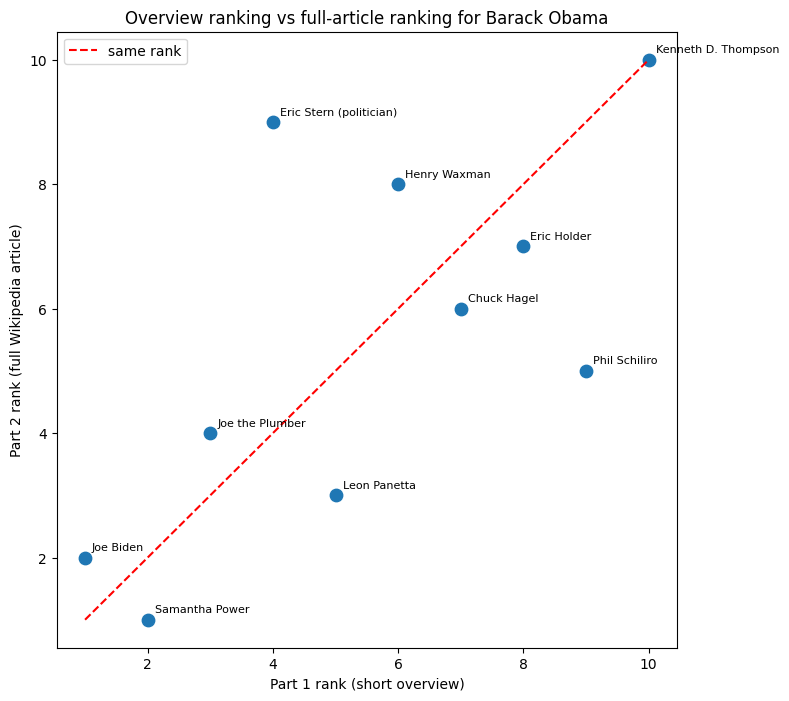

In [20]:
# Plot the comparison: one point per person.
#   x = Part 1 rank (overview),  y = Part 2 rank (full article)
# Points ON the dashed diagonal ranked the SAME both ways; points far OFF it changed
# a lot between the two methods.
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(compare["overview_rank"], compare["wiki_rank"], s=80)

# Label each point with the person's name (skip any with a missing wiki rank).
for _, row in compare.iterrows():
    if pd.notna(row["wiki_rank"]):
        ax.annotate(row["name"],
                    (row["overview_rank"], row["wiki_rank"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

# Diagonal reference line y = x (same rank in both methods).
ax.plot([1, N_NEIGHBORS], [1, N_NEIGHBORS], "r--", label="same rank")
ax.set_xlabel("Part 1 rank (short overview)")
ax.set_ylabel("Part 2 rank (full Wikipedia article)")
ax.set_title("Overview ranking vs full-article ranking for " + REFERENCE_NAME)
ax.legend()
plt.show()


# Part 3 — Interactive: type or choose a name, get the 10 closest people

We wrap the Part 1 logic in a reusable function, then offer two ways to use it: a plain `input()` prompt that works everywhere, and an `ipywidgets` dropdown + search box.


In [21]:
# Reusable function: given a name, return the 10 closest people as a DataFrame.
# Mirrors the Part 1 logic AND its Wikipedia fallback, so the live demo handles
# both dataset names and current single-name stars (e.g. Rihanna).
# Returns None (and prints a hint) only if the name is found nowhere.
def find_closest_people(name, n=N_NEIGHBORS):
    name = name.strip()

    # 1) Dataset first: exact match on the cleaned 'search_name' column.
    hits = people.index[people["search_name"] == name].tolist()
    if len(hits) > 0:
        ref_vector = tfidf[hits[0]]
        dist, ind = nn.kneighbors(ref_vector, n_neighbors=n + 1)
        ind, dist = ind[0][1:], dist[0][1:]            # drop self
    else:
        # 2) Not in the dataset: pull a Wikipedia overview and project it into the
        #    SAME TF-IDF space. No "self" row, so ask for exactly n neighbors.
        overview = get_wiki_overview(name)
        if overview.strip() == "":
            print("'" + name + "' not found in the dataset or on Wikipedia.")
            return None
        print("'" + name + "' not in dataset -- using their Wikipedia overview.")
        ref_vector = vectorizer.transform([overview])
        dist, ind = nn.kneighbors(ref_vector, n_neighbors=n)
        ind, dist = ind[0], dist[0]

    return pd.DataFrame({
        "rank": range(1, n + 1),
        "name": people.loc[ind, "name"].values,
        "distance": dist.round(4),
    })

# Quick test on the reference person.
find_closest_people(REFERENCE_NAME)


,rank,name,distance
0,1,Joe Biden,0.6551
1,2,Samantha Power,0.6911
2,3,Joe the Plumber,0.7069
3,4,Eric Stern (politician),0.7092
4,5,Leon Panetta,0.7232
5,6,Henry Waxman,0.7309
6,7,Chuck Hagel,0.7380
7,8,Eric Holder,0.7492
8,9,Phil Schiliro,0.7499
9,10,Kenneth D. Thompson,0.7625


### Option A — `input()` version (works everywhere)

In [22]:
# Option A -- simplest interactive form: type a name, get the 10 closest people.
# Run this cell, type a name at the prompt, and press Enter.
# COLAB NOTE: the input box appears at the TOP of this cell's output area, not at
# the bottom -- look up there if you do not see it right away.
typed_name = input("Enter a famous person's name: ")
display(find_closest_people(typed_name))


Enter a famous person's name: trump
'trump' not found. Check spelling, or use the search box below.


None

### Option B — widget version (dropdown + search box)

In [23]:
# Option B -- richer interactive form using ipywidgets:
#   1) Type part of a name in the Search box to filter the dropdown.
#   2) Pick a person from the dropdown; the 10 closest update automatically.
# If widgets do not render in your environment, use Option A above instead.
import ipywidgets as widgets

# A text box to filter names, a dropdown of matches, and an output area.
search_box = widgets.Text(description="Search:", placeholder="type part of a name")
name_dropdown = widgets.Dropdown(description="Person:", options=[])
out = widgets.Output()

# A sorted list of the SEARCH names used to populate the dropdown. We drop the
# "Unk Unk" placeholder so the list only contains real, searchable two-word names.
ALL_NAMES = sorted(
    nm for nm in people["search_name"].dropna().unique().tolist()
    if nm != PLACEHOLDER_NAME
)

def update_dropdown(change):
    # Filter names by the search text (case-insensitive). Cap at 200 options so the
    # dropdown stays responsive on 40k+ names.
    query = search_box.value.strip().lower()
    if query == "":
        name_dropdown.options = ALL_NAMES[:200]
    else:
        name_dropdown.options = [nm for nm in ALL_NAMES if query in nm.lower()][:200]

def show_results(change):
    # When a dropdown selection is made, show that person's 10 closest people.
    with out:
        clear_output()
        if name_dropdown.value:
            display(find_closest_people(name_dropdown.value))

# Wire up the events: typing filters the dropdown; selecting shows results.
search_box.observe(update_dropdown, names="value")
name_dropdown.observe(show_results, names="value")

# Initialize the dropdown contents and show the widgets.
update_dropdown(None)
display(search_box, name_dropdown, out)


Text(value='', description='Search:', placeholder='type part of a name')

Dropdown(description='Person:', options=(' Renate Lorenz', '%C3%80lex Rigola', '%C3%81g%C3%BAsta Eva Erlendsd%…

Output()

---
### Presentation note

For the live demo, classmates will suggest a famous person who exists in the DBpedia set. Type their name into the search box (Option B) or run Option A and type it at the prompt — the notebook returns the 10 closest individuals on the spot.
